<a href="https://colab.research.google.com/github/marina-popova11/MediaImpactOnCryptoPrices/blob/training/forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import requests
import pandas as pd
import datetime

def get_crypto_data(coin_id, days=365):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        'vs_currency': 'usd',
        'days': days,
        'interval': 'daily'
    }
    response = requests.get(url, params=params)
    data = response.json()

    prices = data['prices']
    df = pd.DataFrame(prices, columns=['timestamp', 'price'])
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['coin'] = coin_id
    return df[['date', 'coin', 'price']]

In [3]:
BASE_KEYWORDS = [
    "bitcoin", "BTC", "ethereum",
    "ETH", "cryptocurrency", "crypto",
    "blockchain", "ripple", "XRP", "solana", "SOL",
    "digital currency", "virtual currency",
    "token", "altcoin", "stablecoin"
]

TECH_KEYWORDS = [
    "mining", "staking", "halving", "currency exchange rate", "liquidity",
    "phishing", "burning tokens"
]

POLITIC_KEYWORDS = [
    "inflation", "elections", "high tariffs", "legalization of digital currencies", "cryptocurrency laws", "pandemics", "military conflicts"
]

EVENT_KEYWORDS = [
    "growth", "fall", "collapse", "takeoff",
    "regulation", "ban", "investment", "trading",
    "wallet", "exchange", "bullrun", "crash"
]

ENTITY_KEYWORDS = [
    "Coinbase", "CoinGecko", "Elon Musk", "Investment", "trust", "Donald Trump"
]

KEYWORD_GROUPS = {
    "base": BASE_KEYWORDS,
    "tech": TECH_KEYWORDS,
    "politic": POLITIC_KEYWORDS,
    "event": EVENT_KEYWORDS,
    "entity": ENTITY_KEYWORDS
}

In [4]:
import base64
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

CLIENT_ID = "j3iqO3q3iJgDc3R4I1DhvA"
CLIENT_SECRET = "sdDqyyjAKaNhNsbbzXuXaxTfNKN7sA"
USER_AGENT = "CryptoNewsAnalyzer"

def get_reddit_access_token():
    auth_string = f"{CLIENT_ID}:{CLIENT_SECRET}"
    auth_bytes = auth_string.encode('utf-8')
    auth_base64 = base64.b64encode(auth_bytes).decode('utf-8')

    headers = {
        'User-Agent': USER_AGENT,
        'Authorization': f'Basic {auth_base64}'
    }

    data = {
        'grant_type': 'client_credentials',
        'device_id': 'DO_NOT_TRACK_THIS_DEVICE'
    }

    try:
        response = requests.post(
            'https://www.reddit.com/api/v1/access_token',
            headers=headers,
            data=data,
            timeout=10
        )

        if response.status_code == 200:
            token_data = response.json()
            access_token = token_data['access_token']
            print("Successfully obtained Reddit OAuth token")
            return access_token
        else:
            print(f"Failed to get OAuth token: {response.status_code} - {response.text}")
            return None

    except Exception as e:
        print(f"Error getting OAuth token: {e}")
        return None

def fetch_reddit_news_for_window(query: dict, analysis_windows, subreddits=None, posts_per_keyword=100):
    access_token = get_reddit_access_token()
    if not access_token:
        print("Failed to get Reddit OAuth token")
        return pd.DataFrame()

    crypto_subreddits = [
            "CryptoCurrency",
            "CryptoMarkets",
            "bitcoin",
            "ethereum",
            "binance",
            "blockchain",
            "altcoin",
            "defi",
            "CryptoTechnology"
        ]

    if subreddits is None:
        subreddits = crypto_subreddits

    all_posts = []
    all_keywords = [word for words in query.values() for word in words]
    # start = datetime.strptime(start_date, "%Y-%m-%d")
    # end = datetime.strptime(end_date, "%Y-%m-%d")
    headers = {
        'User-Agent': USER_AGENT,
        'Authorization': f'Bearer {access_token}'
    }

    all_dates = list(set([window['volatility_date'] for window in analysis_windows]))
    all_dates.sort()
    print(f"Сбор новостей для {len(analysis_windows)} окон волатильности вокруг дат: {[d.strftime('%Y-%m-%d') for d in all_dates]}")

    for word in all_keywords:
        for subreddit in subreddits:
            print(f"search {subreddit} for {word}")
            url = f"https://oauth.reddit.com/r/{subreddit}/search"
            params = {
                'q': word,
                'limit': posts_per_keyword,
                'restrict_sr': 'on',
                'sort': 'new',
                'type': 'link,self'
            }

            try:
                response = requests.get(url, headers=headers, params=params, timeout=15)
                if response.status_code == 401:
                    print("Token expired. Refreshing...")
                    access_token = get_reddit_access_token()
                    if access_token:
                        headers['Authorization'] = f'Bearer {access_token}'
                        continue
                    else:
                        break

                elif response.status_code == 429:
                    retry_after = int(response.headers.get('Retry-After', 30))
                    print(f"Rate limited. Waiting {retry_after} seconds...")
                    time.sleep(retry_after)
                    continue

                elif response.status_code != 200:
                    print(f"Error {response.status_code} for r/{subreddit}")
                    continue

                data = response.json()
                if 'data' not in data or 'children' not in data['data']:
                    print(f"No data for {subreddit}")
                    continue

                posts = data.get("data", {}).get("children", [])
                posts_count = 0
                for post in posts:
                    post_data = post['data']

                    if post_data.get('removed_by_category'):
                        continue

                    created_utc = post_data.get('created_utc', 0)
                    published_at = datetime.fromtimestamp(created_utc)

                    in_any_window = False
                    matched_window = None
                    for window in analysis_windows:
                        if window['window_start'] <= published_at <= window['window_end']:
                            in_any_window = True
                            matched_window = window['window_label']
                            break
                    if not in_any_window:
                        continue

                    title = post_data.get("title", "") or ""
                    body = post_data.get("selftext", "") or ""
                    text = f"{title}. {body}".lower()

                    matched_keywords = [word for word in all_keywords if word.lower() in text]
                    if not matched_keywords:
                        continue

                    article = {
                        'title': title,
                        'description': body[:500],
                        'publishedAt': published_at,
                        'upvotes': post_data.get('ups', 0),
                        'comments': post_data.get('num_comments', 0),
                        'subreddit': subreddit,
                        'url': f"https://reddit.com{post_data.get('permalink', '')}",
                        'score': post_data.get('score', 0),
                        'window': matched_window,
                        'keyword_matched': ', '.join(matched_keywords)
                    }

                    if (len(article['title']) > 5 and
                            article['upvotes'] >= 5 and article['comments'] > 5):
                        all_posts.append(article)
                        posts_count += 1

                print(f"Found {posts_count} quality posts in r/{subreddit} for {word}")
            except Exception as e:
                print(f"Error getting posts: {e}")

            time.sleep(1)

    if all_posts:
        df = pd.DataFrame(all_posts)
        df["text"] = df[["title", "description"]].astype(str).agg(". ".join, axis=1)
        df["publishedAt"] = pd.to_datetime(df["publishedAt"]).dt.tz_localize(None)
        df.dropna(subset=["text", "publishedAt"], inplace=True)
        df = df.sort_values('publishedAt')
        print(len(df))
        return df
    else:
        return pd.DataFrame()

In [5]:
def categorize_crypto(text):
    text_lower = text.lower()

    bitcoin_keywords = ['bitcoin', 'btc']
    ethereum_keywords = ['ethereum', 'eth']
    binance_keywords = ['binance', 'bnb', 'binance coin']

    bitcoin_match = any(word in text_lower for word in bitcoin_keywords)
    ethereum_match = any(word in text_lower for word in ethereum_keywords)
    binance_match = any(word in text_lower for word in binance_keywords)
    matches = [bitcoin_match, ethereum_match, binance_match]

    if sum(matches) == 1:
        if bitcoin_match: return 'bitcoin'
        if ethereum_match: return 'ethereum'
        if binance_match: return 'binance'

    return 'neutral'

In [6]:
def prepare_price_data(crypto_prices, crypto_name):
    price_data = crypto_prices[crypto_name].copy()
    print(f"Исходные колонки для {crypto_name}: {price_data.columns.tolist()}")
    if isinstance(price_data.columns, pd.MultiIndex):
        price_data.columns = price_data.columns.get_level_values(0)
    price_data = price_data.rename(columns={'price': f'price_{crypto_name}'})
    result = price_data[['window', f'price_{crypto_name}']].copy()
    return result

In [7]:
import pandas as pd
from datetime import datetime, timedelta
import yfinance as yf

def get_crypto_price(start_date ,end_date):
    tickers = {
        'bitcoin': 'BTC-USD',
        'ethereum': 'ETH-USD',
        'binance': 'BNB-USD'
    }

    hourly_prices = {}
    for crypto, ticker in tickers.items():
        try:
            start_datetime = pd.to_datetime(start_date)
            end_datetime = pd.to_datetime(end_date) + timedelta(days=1)

            data = yf.download(ticker, start=start_datetime, end=end_datetime, interval='1h')
            data = data.reset_index()[["Datetime", "Close"]]
            data.rename(columns={"Datetime": "window", "Close": "price"}, inplace=True)
            data["window"]= pd.to_datetime(data["window"])
            data["crypto"] = crypto
            hourly_prices[crypto] = data
            print(f"Успешно загружено {len(data)} записей для {crypto}")

        except Exception as e:
            print(f"Ошибка при загрузке {crypto}: {e}")
    return hourly_prices

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re

def parse_window_column(col):
    # Извлекаем только дату или дату-время из строки
    date_pattern = r'\d{4}-\d{2}-\d{2}(?:[ T]\d{2}:\d{2}:\d{2})?'

    cleaned = col.astype(str).apply(
        lambda s: re.search(date_pattern, s).group(0) if re.search(date_pattern, s) else None
    )

    return pd.to_datetime(cleaned, errors='coerce').dt.tz_localize(None)

def find_best_lag(news_df, price_df, crypto_name, max_lag_hours=48, lag_step=6):
    print("search the best lag")
    news_df = news_df.copy()
    news_df['window'] = parse_window_column(news_df['window'])
    price_df = price_df.copy()
    price_df['window'] = parse_window_column(price_df['window'])
    news_df = news_df.dropna(subset=['window'])
    price_df = price_df.dropna(subset=['window'])

    emb_df = news_df.groupby("window")['embedding'].apply(lambda x: np.mean(np.vstack(x), axis=0)
    ).reset_index()

    best_corr = -1
    best_lag = 0
    best_p_value = 1.0
    best_n_samples = 0
    results = []
    for lag_hour in range(0, max_lag_hours + 1, lag_step):
        price_df_lagged = price_df.copy()
        price_df_lagged['window'] = price_df_lagged['window'] - pd.Timedelta(hours=lag_hour)
        merged_data = pd.merge(emb_df, price_df_lagged, on='window', how='inner')

        if len(merged_data) < 2:
            continue

        price_column = f'price_{crypto_name}'
        merged_data['price_change'] = merged_data[price_column].pct_change()
        merged_data = merged_data.dropna()
        X = np.vstack(merged_data["embedding"])
        y = merged_data["price_change"].values

        X_scaled = StandardScaler().fit_transform(X)
        pca = PCA(n_components=1)
        X_pca = pca.fit_transform(X_scaled).ravel()

        correlation, p_value = spearmanr(X_pca, y)
        if not np.isnan(correlation):
            results.append({
                'lag_hours': lag_hour,
                'correlation': correlation,
                'p_value': p_value,
                'n_samples': len(merged_data)
            })

            abs_correlation = abs(correlation)
            if abs_correlation > best_corr:
                best_corr = abs_correlation
                best_lag = lag_hour
                best_p_value = p_value
                best_n_samples = len(merged_data)
    print(f"Протестировано {len(results)} лагов для {crypto_name}")
    if results:
        print(f"ОПТИМАЛЬНЫЙ ЛАГ ДЛЯ {crypto_name.upper()}: {best_lag} часов")
        print(f"Корреляция: {best_corr:.3f}")
        print(f"p-value: {best_p_value:.3f}")
        print(f"Количество образцов: {best_n_samples}")

        plt.figure(figsize=(10, 6))
        lags = [r['lag_hours'] for r in results]
        correlations = [r['correlation'] for r in results]

        plt.plot(lags, correlations, 'o-', linewidth=2, markersize=8,
                label=f'{crypto_name} корреляция')
        plt.axvline(x=best_lag, color='red', linestyle='--',
                    label=f'Оптимальный лаг: {best_lag}ч')
        plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

        plt.title(f'Зависимость корреляции от лага ({crypto_name})')
        plt.xlabel('Лаг (часы)')
        plt.ylabel('Корреляция Спирмена')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        return best_lag, results
    else:
        print(f"Не удалось найти значимые корреляции для {crypto_name}")
        return 0, []

In [9]:
import numpy as np
import pandas as pd
import torch

class BertEmbeddingExtractor:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()
        print(f"model downloaded to {self.device}")

    def get_embeddings(self, text, batch_size=32):
        embeddings = []
        print("извлечение эмбеддингов")
        with torch.no_grad():
            for i in range(0, len(text), batch_size):
                batch_text = text[i : i + batch_size]
                inputs = self.tokenizer(
                    batch_text,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=256
                ).to(self.device)

                outputs = self.model(**inputs)
                batch_embeddings = outputs.last_hidden_state[:, 0, :]
                embeddings.append(batch_embeddings.cpu().numpy())

        return np.vstack(embeddings)


In [41]:
import numpy as np
import pandas as pd
import torch
from datetime import datetime, timedelta
from transformers import pipeline, AutoModel, AutoTokenizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

class CryptoNewsPredictor:
    def __init__(self, model=model, tokenizer=tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.embedding_extractor = BertEmbeddingExtractor(self.model, self.tokenizer)
        self.sentiment_analyzer = None
        self.price_predictor = None
        self.direction_predictor = None
        self.scaler = StandardScaler()

    def prepare_training_data(self, news_df, price_returns_df, crypto_prices_dict):
        """Подготовка данных для обучения на основе обоих подходов"""
        print("🔍 ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ...")
        news_df["window"] = (
            news_df["window"].astype(str)
            .str.replace(r'^[A-Za-z]+_', '', regex=True)
        )

        news_df["emb_dim"] = news_df["embedding"].apply(lambda x: len(x))
        print(news_df["emb_dim"].value_counts())

        news_df['window'] = pd.to_datetime(news_df['window'], utc=True)
        for crypto_name, df in crypto_prices_dict.items():
            df['window'] = pd.to_datetime(df['window'], utc=True)

        # 1. Получаем оптимальные лаги для каждой валюты
        optimal_lags = self._find_optimal_lag(news_df, crypto_prices_dict)

        training_data = []

        for crypto_name in ['bitcoin', 'ethereum', 'binance']:
            print(f"Обработка {crypto_name}...")

            print(news_df.head())
            # Фильтруем новости по категории
            crypto_news = self._filter_news_by_crypto(news_df, crypto_name)

            if len(crypto_news) == 0:
                continue

            # Применяем оптимальный лаг
            optimal_lag = optimal_lags.get(crypto_name, 0)
            print(crypto_prices_dict[crypto_name].columns)
            merged_data = self._apply_lag_and_merged(crypto_news, crypto_prices_dict[crypto_name], crypto_name, optimal_lag)

            if len(merged_data) == 0:
                print("merged_data is empty")
                continue
            print(merged_data.columns)
            # Создаем фичи для каждой новости
            for idx, row in merged_data.iterrows():
                print(row)
                print(row['window'], row['window'].tzinfo)
                features = self._extract_features_from_news(row)
                features['optimal_lag'] = optimal_lag
                features['crypto_name'] = crypto_name

                print(len(features))
                # Целевая переменная - изменение цены через N часов
                price_change = self._calculate_future_price_change(
                    row['window'], crypto_prices_dict[crypto_name], hours_ahead=optimal_lag
                )

                print("price_change:", price_change, type(price_change))

                if price_change is not None:
                    features['price_change'] = price_change
                    features['price_direction'] = 1 if price_change > 0 else 0
                    training_data.append(features)

        return pd.DataFrame(training_data)

    def _extract_features_from_news(self, news_row):
        """Извлечение признаков из новости"""
        features = {}

        embedding = news_row['embedding']

        for i in range(min(10, len(embedding))):
            features[f'embedding_{i}'] = embedding[i]

        text = news_row['text']

        sentiment_score = self._predict_sentiment([text])[0]
        features['sentiment'] = sentiment_score
        features['sentiment_abs'] = abs(sentiment_score)

        # 3. Мета-признаки новости
        features['text_length'] = len(text)
        features['has_positive_words'] = int(any(word in text.lower() for word in
                                               ['growth', 'bullish', 'profit', 'gain', 'positive']))
        features['has_negative_words'] = int(any(word in text.lower() for word in
                                               ['crash', 'bearish', 'loss', 'drop', 'negative']))

        # 4. Временные признаки
        publish_time = news_row['window']
        features['hour'] = publish_time.hour
        features['day_of_week'] = publish_time.dayofweek
        features['is_weekend'] = int(publish_time.dayofweek >= 5)

        return features

    def train_prediction_models(self, training_df):
        """Обучение моделей прогнозирования"""
        print("🎯 ОБУЧЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ...")

        # Подготовка данных
        feature_columns = [col for col in training_df.columns if col not in
                         ['price_change', 'price_direction', 'crypto_name']]
        X = training_df[feature_columns]
        y_regression = training_df['price_change']  # для регрессии (величина изменения)
        y_classification = training_df['price_direction']  # для классификации (направление)

        # Масштабирование признаков
        X_scaled = self.scaler.fit_transform(X)

        # Разделение на train/test
        X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
            X_scaled, y_regression, y_classification, test_size=0.2, random_state=42
        )

        # Модель для прогнозирования величины изменения цены
        self.price_predictor = RandomForestRegressor(n_estimators=100, random_state=42)
        self.price_predictor.fit(X_train, y_reg_train)

        # Модель для прогнозирования направления (рост/падение)
        self.direction_predictor = RandomForestClassifier(n_estimators=100, random_state=42)
        self.direction_predictor.fit(X_train, y_clf_train)

        # Оценка качества
        reg_score = self.price_predictor.score(X_test, y_reg_test)
        clf_score = self.direction_predictor.score(X_test, y_clf_test)

        print(f"✅ Модели обучены!")
        print(f"   Регрессия (R²): {reg_score:.3f}")
        print(f"   Классификация (Accuracy): {clf_score:.3f}")

        return reg_score, clf_score

    def predict_from_new_news(self, news_text, crypto_name='bitcoin'):
        """Прогнозирование на основе новой новости"""
        if self.price_predictor is None:
            raise ValueError("Модели не обучены! Сначала вызовите train_prediction_models()")

        # Извлекаем признаки из новости
        features = self._extract_features_from_single_news(news_text, crypto_name)

        # Масштабирование
        feature_columns = [col for col in features.columns if col != 'crypto_name']
        X_scaled = self.scaler.transform(features[feature_columns])

        # Прогнозирование
        price_change_pred = self.price_predictor.predict(X_scaled)[0]
        direction_pred = self.direction_predictor.predict(X_scaled)[0]
        direction_proba = self.direction_predictor.predict_proba(X_scaled)[0]

        return {
            'predicted_price_change': price_change_pred,
            'predicted_direction': 'РОСТ 📈' if direction_pred == 1 else 'ПАДЕНИЕ 📉',
            'confidence': max(direction_proba),
            'probability_up': direction_proba[1],
            'probability_down': direction_proba[0]
        }

    def _extract_features_from_single_news(self, news_text, crypto_name):
        """Извлечение признаков из одной новости"""
        features = {}

        # Эмбеддинги
        embedding = self.embedding_extractor.get_embeddings([news_text])[0]
        for i in range(min(10, len(embedding))):
            features[f'embedding_{i}'] = embedding[i]

        # Тональность
        sentiment_score = self._predict_sentiment([news_text])[0]
        features['sentiment'] = sentiment_score
        features['sentiment_abs'] = abs(sentiment_score)

        # Мета-признаки
        features['text_length'] = len(news_text)
        features['has_positive_words'] = int(any(word in news_text.lower() for word in
                                               ['growth', 'bullish', 'profit', 'gain', 'positive']))
        features['has_negative_words'] = int(any(word in news_text.lower() for word in
                                               ['crash', 'bearish', 'loss', 'drop', 'negative']))

        # Временные признаки (текущее время)
        current_time = datetime.now()
        features['hour'] = current_time.hour
        features['day_of_week'] = current_time.weekday()
        features['is_weekend'] = int(current_time.weekday() >= 5)

        # Оптимальный лаг (можно настроить для каждой валюты)
        optimal_lags = {'bitcoin': 6, 'ethereum': 12, 'binance': 18}  # примерные значения
        features['optimal_lag'] = optimal_lags.get(crypto_name, 12)
        features['crypto_name'] = crypto_name

        return pd.DataFrame([features])

    def _create_sentiment_pipeline(self):
        from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
        try:
            sentiment_model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
            sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
            sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name)
            sentiment_analyzer = pipeline(
                "sentiment-analysis",
                model=sentiment_model,
                tokenizer=sentiment_tokenizer,
                device=0 if torch.cuda.is_available() else -1,
                truncation=True,
                max_length=512
            )
            print("Пайплайн для анализа тональности создан")
            return sentiment_analyzer
        except Exception as e:
            print(f"Ошибка создания пайплайна: {e}")
            return None

    def _predict_sentiment(self, texts):
        if self.sentiment_analyzer is None:
            self.sentiment_analyzer = self._create_sentiment_pipeline()

        sentiment_scores = []
        batch_size = 16
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            try:
                results = self.sentiment_analyzer(batch_texts)

                for result in results:
                    label = result['label'].lower()
                    score = result['score']

                    if "neg" in label:
                        sentiment_scores.append(-score)
                    elif "pos" in label:
                        sentiment_scores.append(score)
                    else:
                        sentiment_scores.append(0.0)

            except Exception as e:
                print(f"Ошибка при анализе тональности: {e}")
                sentiment_scores.extend([0.0] * len(batch_texts))

        return sentiment_scores

    def _find_optimal_lag(self, news_df, crypto_prices_dict):
        optimal_lags = {}
        for crypto_name in crypto_prices_dict.keys():
            price_data = prepare_price_data(crypto_prices_dict, crypto_name)
            optimal_lag, _ = find_best_lag(news_df, price_data, crypto_name)
            optimal_lags[crypto_name] = optimal_lag
        return optimal_lags

    def _normalize_price_df_columns(self, df):
        """Приводит MultiIndex прайсовых данных к обычным колонкам"""
        df = df.copy()
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [
                col[0] if col[0] != "" else col[1]
                for col in df.columns
            ]

        # Теперь ожидаем:
        # window, price(BTC-USD), crypto
        # Приведём к стандартной форме

        if "window" not in df.columns:
            raise ValueError("В price_df нет столбца 'window'")

        price_cols = [c for c in df.columns if "price" in c.lower()]
        if len(price_cols) == 0:
            raise ValueError("В price_df нет price-колонок")

        # Берём первую цену
        df.rename(columns={price_cols[0]: "price"}, inplace=True)

        return df

    def _apply_lag_and_merged(self, news_df, price_df, crypto_name, optimal_lag):
        news_df = news_df.copy()
        price_df = self._normalize_price_df_columns(price_df)

        news_df["window"] = (
            news_df["window"].astype(str)
            .str.replace(r'^[A-Za-z]+_', '', regex=True)
        )

        news_df["window"] = pd.to_datetime(news_df["window"], errors="coerce")
        news_df = news_df.dropna(subset=["window"])
        news_df["window"] = news_df["window"].dt.tz_localize(None)

        price_df["window"] = pd.to_datetime(price_df["window"], errors="coerce")
        price_df = price_df.dropna(subset=["window"])
        price_df["window"] = price_df["window"].dt.tz_localize(None)

        emb_df = (
            news_df.groupby("window")
            .agg({
                "embedding": lambda x: np.mean(np.vstack(x), axis=0),
                "text": lambda x: "\n\n".join(x)
            }).reset_index()
        )
        price_df_lagged = price_df.copy()
        price_df_lagged['window'] = price_df_lagged['window'] - pd.Timedelta(hours=optimal_lag)

        merged_data = pd.merge(emb_df, price_df_lagged, on='window', how='inner')
        print(f"[{crypto_name}] Объединенные данные: {len(merged_data)} записей")
        return merged_data


    def _filter_news_by_crypto(self, news_df, crypto_name):
        news_df = news_df.copy()
        news_df['crypto_category'] = news_df['text'].apply(categorize_crypto)
        filtered_news = news_df[news_df['crypto_category'].isin([crypto_name, 'neutral'])].copy()
        return filtered_news

    def _calculate_future_price_change(self, timestamp, price_df, hours_ahead):
        """Расчет изменения цены в будущем"""
        try:
            current_time = pd.to_datetime(timestamp, utc=True)
            future_time = current_time + timedelta(hours=hours_ahead)

            # Находим ближайшие доступные цены
            current_price = self._find_nearest_price(price_df, current_time)
            future_price = self._find_nearest_price(price_df, future_time)

            if current_price is not None and future_price is not None:
                return (future_price - current_price) / current_price * 100
        except:
            print("ERROR in _calculate_future_price_change:", e)
        return None

    def _find_nearest_price(self, price_df, target_time):
        """Нахождение ближайшей доступной цены"""
        try:
            price_df = price_df.copy()
            price_df['time_diff'] = abs(price_df['window'] - target_time)

            print(price_df[['window','time_diff']].head())

            nearest_idx = price_df['time_diff'].idxmin()
            print("nearest_idx:", nearest_idx)

            val = price_df.loc[nearest_idx, 'price']
            if isinstance(val, pd.Series):
                return val.iloc[0]
            return val
        except Exception as e:
            print("⚠ ERROR in _find_nearest_price:", e)
            return None

    def save_models(self, path='crypto_predictor_models.joblib'):
        """Сохранение обученных моделей"""
        model_data = {
            'price_predictor': self.price_predictor,
            'direction_predictor': self.direction_predictor,
            'scaler': self.scaler
        }
        joblib.dump(model_data, path)
        print(f"✅ Модели сохранены в {path}")

    def load_models(self, path='crypto_predictor_models.joblib'):
        """Загрузка обученных моделей"""
        model_data = joblib.load(path)
        self.price_predictor = model_data['price_predictor']
        self.direction_predictor = model_data['direction_predictor']
        self.scaler = model_data['scaler']
        print(f"✅ Модели загружены из {path}")

In [12]:
import pandas as pd
from datetime import datetime, timedelta
import time
import numpy as np
import os

print("📁 Содержимое /content/drive/MyDrive:")
try:
    contents = os.listdir('/content/drive/MyDrive')
    for item in contents:
        full_path = f"/content/drive/MyDrive/{item}"
        if os.path.isdir(full_path):
            print(f"📁 {item}")
        else:
            print(f"📄 {item}")

    # Проверим конкретно нашу папку
    target_path = '/content/drive/MyDrive/fine_tuned_bert1'
    print(f"\n🔍 Проверяем путь: {target_path}")
    print(f"Существует: {os.path.exists(target_path)}")

    if os.path.exists(target_path):
        print("✅ Папка найдена! Содержимое:")
        for file in os.listdir(target_path):
            print(f"   - {file}")

except Exception as e:
    print(f"Ошибка: {e}")

📁 Содержимое /content/drive/MyDrive:
📁 Colab Notebooks
📄 2_5210836082228223740.gdoc
📁 crypto_sentiment_dataset
📁 fine_tuned_bert1

🔍 Проверяем путь: /content/drive/MyDrive/fine_tuned_bert1
Существует: True
✅ Папка найдена! Содержимое:
   - special_tokens_map.json
   - training_args.bin
   - config.json
   - tokenizer.json
   - vocab.txt
   - tokenizer_config.json
   - model.safetensors


In [13]:
import pandas as pd
import shutil
from datetime import datetime, timedelta
import time
import numpy as np
import os

print("🚀 ЗАПУСК СИСТЕМЫ ПРОГНОЗИРОВАНИЯ КРИПТОВАЛЮТ")

# 1. Загрузка модели BERT
model_full_path = '/content/drive/MyDrive/fine_tuned_bert1'
model_path = '/content/fine_tuned_bert1'
if os.path.exists(model_full_path):
    shutil.copytree(model_full_path, model_path, dirs_exist_ok=True)
    print("Модель найдена в Google Drive")
    model = AutoModel.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    print("Модель загружена!")
else:
    print("Модель не найдена. Проверьте путь:")
    print("Содержимое MyDrive:")
    print(os.listdir('/content/drive/MyDrive'))

# 2. Загрузка ценовых данных
print("📊 Загрузка данных о ценах...")
try:
    btc_df = get_crypto_data('bitcoin')
    eth_df = get_crypto_data('ethereum')
    bnb_df = get_crypto_data('binancecoin')
    price_df = pd.concat([btc_df, eth_df, bnb_df], ignore_index=True)
    print(price_df.shape)
    print(price_df.head(20))
    print(price_df["coin"].value_counts())
    print("✅ Данные о ценах загружены")
except Exception as e:
    print(f"❌ Ошибка загрузки данных о ценах: {e}")

# 3. Анализ волатильности
print("📈 Анализ волатильности...")
pivot_df = price_df.pivot(index='date', columns='coin', values='price')
returns_df = pivot_df.pct_change() * 100
print(pivot_df.head(20))
print(returns_df.head(20))

RECOMMENDED_THRESHOLDS = {
    'bitcoin': 5.0,
    'ethereum': 7.0,
    'binancecoin': 8.0
}

volatile_periods = {}
for coin in returns_df.columns:
    threshold = RECOMMENDED_THRESHOLDS.get(coin, 8.0)
    high_volatility = returns_df[(returns_df[coin] > threshold) | (returns_df[coin] < -threshold)]
    volatile_periods[coin] = high_volatility.index.tolist()
    print(f"Периоды высокой волатильности для {coin}: {len(volatile_periods[coin])}")


# 4. Создание окон для сбора новостей
analysis_windows = []
for coin, volatile_dates in volatile_periods.items():
    for v_date in volatile_dates:
        window_start = v_date - timedelta(days=2)
        window_end = v_date + timedelta(days=2)

        analysis_windows.append({
            'coin': coin,
            'volatility_date': v_date,
            'window_start': window_start,
            'window_end': window_end,
            'window_label': f"{coin}_{v_date.strftime('%Y-%m-%d')}"
        })

print(f"📅 Создано {len(analysis_windows)} окон для анализа")

🚀 ЗАПУСК СИСТЕМЫ ПРОГНОЗИРОВАНИЯ КРИПТОВАЛЮТ
Модель найдена в Google Drive
Модель загружена!
📊 Загрузка данных о ценах...
(1098, 3)
         date     coin         price
0  2024-11-17  bitcoin  90606.454894
1  2024-11-18  bitcoin  89841.471941
2  2024-11-19  bitcoin  90534.624597
3  2024-11-20  bitcoin  92251.652407
4  2024-11-21  bitcoin  94217.022296
5  2024-11-22  bitcoin  98509.118591
6  2024-11-23  bitcoin  98927.494946
7  2024-11-24  bitcoin  97679.463816
8  2024-11-25  bitcoin  98015.935529
9  2024-11-26  bitcoin  93004.700931
10 2024-11-27  bitcoin  91931.830773
11 2024-11-28  bitcoin  95981.180572
12 2024-11-29  bitcoin  95661.595958
13 2024-11-30  bitcoin  97453.247345
14 2024-12-01  bitcoin  96513.142347
15 2024-12-02  bitcoin  97311.707191
16 2024-12-03  bitcoin  95833.136230
17 2024-12-04  bitcoin  96031.630978
18 2024-12-05  bitcoin  98881.469456
19 2024-12-06  bitcoin  97201.500364
coin
bitcoin        366
ethereum       366
binancecoin    366
Name: count, dtype: int64
✅ Д

/tmp/ipython-input-2209231727.py:41: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = pivot_df.pct_change() * 100


In [14]:
# 5. Сбор новостей
print("📰 Сбор новостей с Reddit...")
data_reddit = fetch_reddit_news_for_window(KEYWORD_GROUPS, analysis_windows)

print(len(data_reddit))
print(data_reddit.head())
data_reddit.to_csv("crypto_news_volatility_periods.csv", index=False, encoding='utf-8-sig')

📰 Сбор новостей с Reddit...
Successfully obtained Reddit OAuth token
Сбор новостей для 49 окон волатильности вокруг дат: ['2024-11-22', '2024-11-26', '2024-11-28', '2024-12-04', '2024-12-10', '2024-12-19', '2025-01-08', '2025-02-03', '2025-02-13', '2025-02-25', '2025-02-27', '2025-03-03', '2025-03-04', '2025-03-10', '2025-03-12', '2025-04-07', '2025-04-10', '2025-04-11', '2025-04-23', '2025-05-09', '2025-05-11', '2025-05-14', '2025-06-06', '2025-06-10', '2025-06-24', '2025-07-03', '2025-07-17', '2025-08-13', '2025-08-23', '2025-08-26', '2025-10-04', '2025-10-11', '2025-10-13', '2025-11-04', '2025-11-05', '2025-11-15']
search CryptoCurrency for bitcoin
Found 22 quality posts in r/CryptoCurrency for bitcoin
search CryptoMarkets for bitcoin
Found 26 quality posts in r/CryptoMarkets for bitcoin
search bitcoin for bitcoin
Found 27 quality posts in r/bitcoin for bitcoin
search ethereum for bitcoin
Found 14 quality posts in r/ethereum for bitcoin
search binance for bitcoin
Found 3 quality pos

In [15]:
import pandas as pd
from datetime import datetime, timedelta
import time
import numpy as np

# 6. Создание эмбеддингов для новостей
print("🔤 Создание эмбеддингов для новостей...")
embedding_extractor = BertEmbeddingExtractor(model, tokenizer)

def process_dataset_to_embeddings(dataset, text_column='text', date_column='window'):
    texts = dataset[text_column].tolist()
    dates = dataset[date_column].tolist()
    embeddings = embedding_extractor.get_embeddings(texts)
    result_df = pd.DataFrame({
        'window': dates,
        'text': texts,
        'embedding': list(embeddings)
    })
    return result_df

result_with_embeddings = process_dataset_to_embeddings(data_reddit)
print(result_with_embeddings.head())

🔤 Создание эмбеддингов для новостей...
model downloaded to cuda
извлечение эмбеддингов
                window                                               text  \
0  ethereum_2024-11-22  Next Devcon location?. **Devcon 2024 was an ab...   
1  ethereum_2024-11-22  Honeypots on Base. Hello, friends.\n\nI'm writ...   
2  ethereum_2024-11-22  Portfolio advice needed. 100% BTC vs. 50% BTC ...   
3  ethereum_2024-11-22  UEEx Is Offering UE and BTC Rewards for Their ...   
4  ethereum_2024-11-22  UEEx Is Offering UE and BTC Rewards for Their ...   

                                           embedding  
0  [0.06752233, 0.05891898, 0.48756388, -0.087998...  
1  [-0.029620117, 0.15105574, 0.6021373, -0.03222...  
2  [-0.102982104, 0.2340929, 0.7277649, -0.054743...  
3  [0.2329021, -0.40889615, 0.51686275, -0.127623...  
4  [0.2329021, -0.40889615, 0.51686275, -0.127623...  


⏰ Загрузка часовых данных о ценах...


/tmp/ipython-input-1173328357.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_datetime, end=end_datetime, interval='1h')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1173328357.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_datetime, end=end_datetime, interval='1h')


Успешно загружено 8672 записей для bitcoin


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1173328357.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_datetime, end=end_datetime, interval='1h')


Успешно загружено 8669 записей для ethereum


[*********************100%***********************]  1 of 1 completed


Успешно загружено 8672 записей для binance
🎯 Создание модели прогнозирования...
model downloaded to cuda
🔍 ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ...
emb_dim
768    2471
Name: count, dtype: int64
Исходные колонки для bitcoin: [('window', ''), ('price', 'BTC-USD'), ('crypto', '')]
search the best lag
Протестировано 9 лагов для bitcoin
ОПТИМАЛЬНЫЙ ЛАГ ДЛЯ BITCOIN: 24 часов
Корреляция: 0.357
p-value: 0.035
Количество образцов: 35


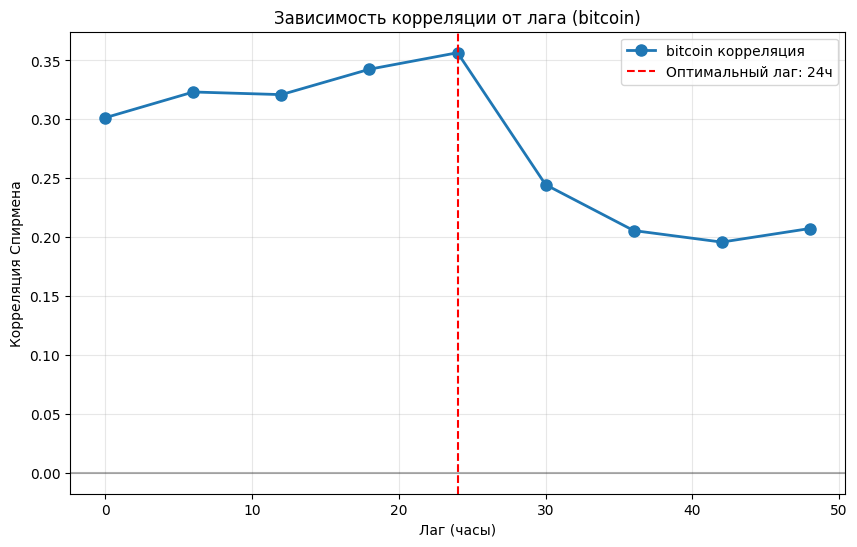

Исходные колонки для ethereum: [('window', ''), ('price', 'ETH-USD'), ('crypto', '')]
search the best lag
Протестировано 9 лагов для ethereum
ОПТИМАЛЬНЫЙ ЛАГ ДЛЯ ETHEREUM: 24 часов
Корреляция: 0.285
p-value: 0.098
Количество образцов: 35


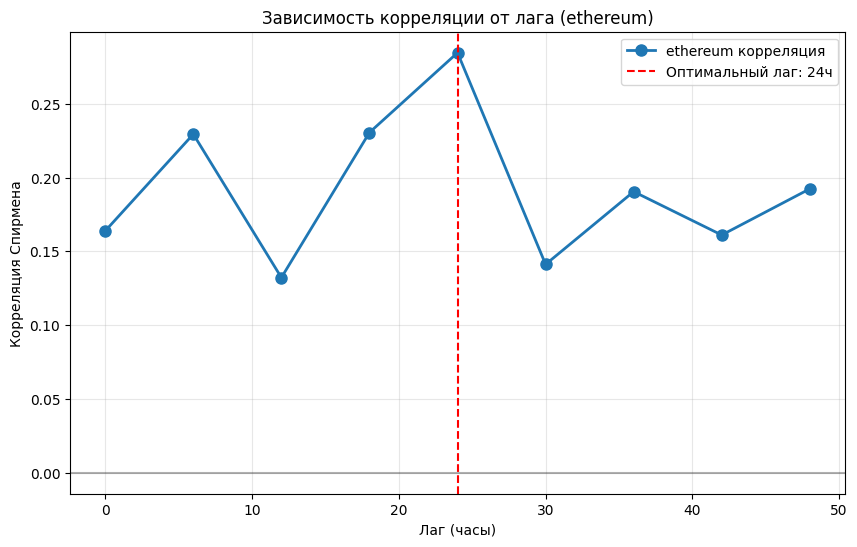

Исходные колонки для binance: [('window', ''), ('price', 'BNB-USD'), ('crypto', '')]
search the best lag
Протестировано 9 лагов для binance
ОПТИМАЛЬНЫЙ ЛАГ ДЛЯ BINANCE: 18 часов
Корреляция: 0.336
p-value: 0.048
Количество образцов: 35


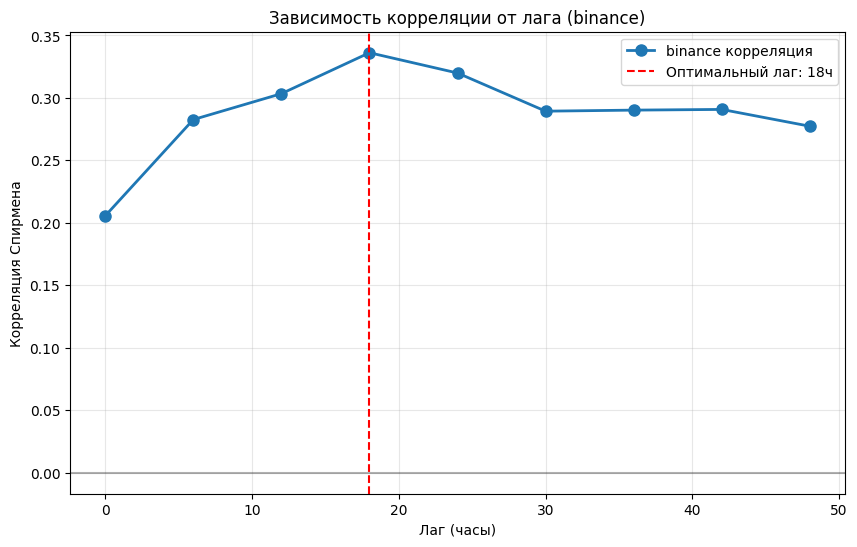

Обработка bitcoin...
                     window  \
0 2024-11-22 00:00:00+00:00   
1 2024-11-22 00:00:00+00:00   
2 2024-11-22 00:00:00+00:00   
3 2024-11-22 00:00:00+00:00   
4 2024-11-22 00:00:00+00:00   

                                                text  \
0  Next Devcon location?. **Devcon 2024 was an ab...   
1  Honeypots on Base. Hello, friends.\n\nI'm writ...   
2  Portfolio advice needed. 100% BTC vs. 50% BTC ...   
3  UEEx Is Offering UE and BTC Rewards for Their ...   
4  UEEx Is Offering UE and BTC Rewards for Their ...   

                                           embedding  emb_dim  
0  [0.06752233, 0.05891898, 0.48756388, -0.087998...      768  
1  [-0.029620117, 0.15105574, 0.6021373, -0.03222...      768  
2  [-0.102982104, 0.2340929, 0.7277649, -0.054743...      768  
3  [0.2329021, -0.40889615, 0.51686275, -0.127623...      768  
4  [0.2329021, -0.40889615, 0.51686275, -0.127623...      768  
MultiIndex([('window',        ''),
            ( 'price', 'BTC-USD'),
 

Device set to use cuda:0


Пайплайн для анализа тональности создан
20
Price                     window       time_diff
Ticker                                          
0      2024-11-20 00:00:00+00:00 2 days 00:00:00
1      2024-11-20 01:00:00+00:00 1 days 23:00:00
2      2024-11-20 02:00:00+00:00 1 days 22:00:00
3      2024-11-20 03:00:00+00:00 1 days 21:00:00
4      2024-11-20 04:00:00+00:00 1 days 20:00:00
nearest_idx: 48
Price                     window       time_diff
Ticker                                          
0      2024-11-20 00:00:00+00:00 3 days 00:00:00
1      2024-11-20 01:00:00+00:00 2 days 23:00:00
2      2024-11-20 02:00:00+00:00 2 days 22:00:00
3      2024-11-20 03:00:00+00:00 2 days 21:00:00
4      2024-11-20 04:00:00+00:00 2 days 20:00:00
nearest_idx: 72
price_change: 0.7505963753762702 <class 'numpy.float64'>
window                                     2024-11-26 00:00:00
embedding    [0.20418228, -0.16607864, 0.30019975, -0.08348...
text         Why it is apparently not the bull run for a

In [42]:
import pandas as pd
from datetime import datetime, timedelta
import time
import numpy as np

# 7. Загрузка часовых данных о ценах
print("⏰ Загрузка часовых данных о ценах...")
start_date = data_reddit['publishedAt'].min().date()
end_date = data_reddit['publishedAt'].max().date()
crypto_prices = get_crypto_price(start_date, end_date)

# 8. Создание и обучение модели прогнозирования
print("🎯 Создание модели прогнозирования...")
predictor = CryptoNewsPredictor(model, tokenizer)

# Подготовка данных для обучения
training_data = predictor.prepare_training_data(
    result_with_embeddings,
    returns_df,
    crypto_prices
)

print("🔎 Готовая обучающая выборка:", training_data.shape)
print(training_data.head())

In [43]:
if len(training_data) == 0:
    print("❌ Недостаточно данных для обучения")

# Обучение моделей
reg_score, clf_score = predictor.train_prediction_models(training_data)

# Сохранение моделей
predictor.save_models()

# 9. Тестирование прогнозирования
print("\n🧪 ТЕСТИРОВАНИЕ ПРОГНОЗИРОВАНИЯ:")
test_news = [
    "Bitcoin breaks all-time high as institutional investors pour billions into crypto",
    "Major exchange hacked: Millions in cryptocurrency stolen in security breach",
]

for news in test_news:
    prediction = predictor.predict_from_new_news(news, 'bitcoin')
    print(f"\n📰 Новость: {news}")
    print(f"💰 Прогноз: {prediction['predicted_direction']} ({prediction['predicted_price_change']:.2f}%)")
    print(f"🎯 Уверенность: {prediction['confidence']:.1%}")
    print(f"📊 Вероятность роста: {prediction['probability_up']:.1%}")

print("\n✅ СИСТЕМА ПРОГНОЗИРОВАНИЯ ГОТОВА К РАБОТЕ!")

🎯 ОБУЧЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ...
✅ Модели обучены!
   Регрессия (R²): 0.232
   Классификация (Accuracy): 0.636
✅ Модели сохранены в crypto_predictor_models.joblib

🧪 ТЕСТИРОВАНИЕ ПРОГНОЗИРОВАНИЯ:
извлечение эмбеддингов

📰 Новость: Bitcoin breaks all-time high as institutional investors pour billions into crypto
💰 Прогноз: РОСТ 📈 (0.52%)
🎯 Уверенность: 54.0%
📊 Вероятность роста: 54.0%
извлечение эмбеддингов

📰 Новость: Major exchange hacked: Millions in cryptocurrency stolen in security breach
💰 Прогноз: ПАДЕНИЕ 📉 (-1.30%)
🎯 Уверенность: 68.0%
📊 Вероятность роста: 32.0%

✅ СИСТЕМА ПРОГНОЗИРОВАНИЯ ГОТОВА К РАБОТЕ!
